In [ ]:
!pip install diffusers["torch"]

In [1]:
# ============================================================
# TEXT-TO-IMAGE MODEL LOADER
# (RUN THIS CELL ONLY ONCE IN JUPYTER LAB)
# ============================================================

import os
import torch
import warnings
from diffusers import StableDiffusionXLPipeline
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# Suppress unnecessary warnings for clean notebook output
# ------------------------------------------------------------
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Device & Precision Configuration
# ------------------------------------------------------------
# - CUDA + float16 → Faster & memory-efficient
# - CPU + float32 → Stable fallback
# ------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print(f" Running on device : {device}")
print(f" Torch data type  : {dtype}")

# ------------------------------------------------------------
# Load SDXL Pipeline from single safetensors file
# ------------------------------------------------------------
pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=dtype,
    add_watermarker=False       # Clean outputs (no watermark)
)

# Move pipeline to selected device (GPU / CPU)
pipe.to(device)

# ------------------------------------------------------------
# Memory Optimization (Important for Jupyter & Low VRAM GPUs)
# ------------------------------------------------------------
pipe.enable_attention_slicing()
pipe.enable_vae_slicing()

print("✅ SDXL model loaded successfully and ready for inference")

2026-01-08 15:36:12.446817: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767886572.471832    5160 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767886572.482242    5160 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-08 15:36:12.666975: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


 Running on device : cuda
 Torch data type  : torch.float16


Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


✅ SDXL model loaded successfully and ready for inference


Prompt:
Iron Man in advanced iron armor Standing on stone, cinematic sunset lighting, dramatic sky, reflective metal surfaces, heroic pose, detailed armor, sharp focus, epic movie scene

 Generating image...


  0%|          | 0/28 [00:00<?, ?it/s]

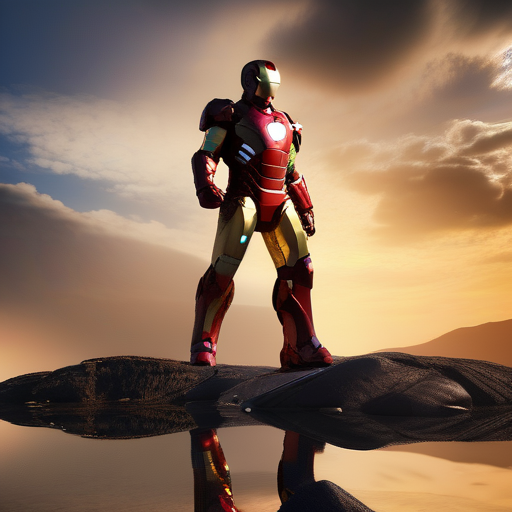


⏱ Generation time: 6.2 seconds


In [2]:
# ============================================================
# (RUN THIS CELL TO GENERATE IMAGES FROM TEXT PROMPTS)
# ============================================================

import time
from IPython.display import display

# ------------------------------------------------------------
# TEXT PROMPT
# Keep prompts concise and descriptive (≈ 70–80 tokens max)
# ------------------------------------------------------------
prompt = 'Iron Man in advanced iron armor Standing on stone, cinematic sunset lighting, dramatic sky, reflective metal surfaces, heroic pose, detailed armor, sharp focus, epic movie scene'

# ------------------------------------------------------------
# NEGATIVE PROMPT
# Helps remove common generation issues
# ------------------------------------------------------------
negative_prompt = 'cartoon, anime, illustration, blurry, low quality, distorted face, extra limbs, extra fingers, deformed armor, bad proportions, watermark, logo, text'

# ------------------------------------------------------------
# GENERATION PARAMETERS (Balanced & Stable Defaults)
# ------------------------------------------------------------
width = 512
height = 512
num_inference_steps = 28     # More steps = better detail (slower)
guidance_scale = 6.5        # Prompt adherence vs creativity
generator = None            # None → more randomness & creativity

# ------------------------------------------------------------
# Inference Execution
# ------------------------------------------------------------
print("Prompt:")
print(prompt)
print("\n Generating image...")

start_time = time.time()

# Disable gradient tracking for faster & memory-safe inference
with torch.no_grad():
    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        width=width,
        height=height,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        generator=generator,
    )

# Extract generated image
image = result.images[0]

# Display inside Jupyter Notebook
display(image)

print(f"\n⏱ Generation time: {time.time() - start_time:.1f} seconds")